In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
project_root='/home/g202393750/Documents/Superresolution/The definitive model/'
sys.path.append(project_root)

import numpy as np
from Utils.utils_modif import *

test_data_base=f"{project_root}Data/Train/original/"

# Importation

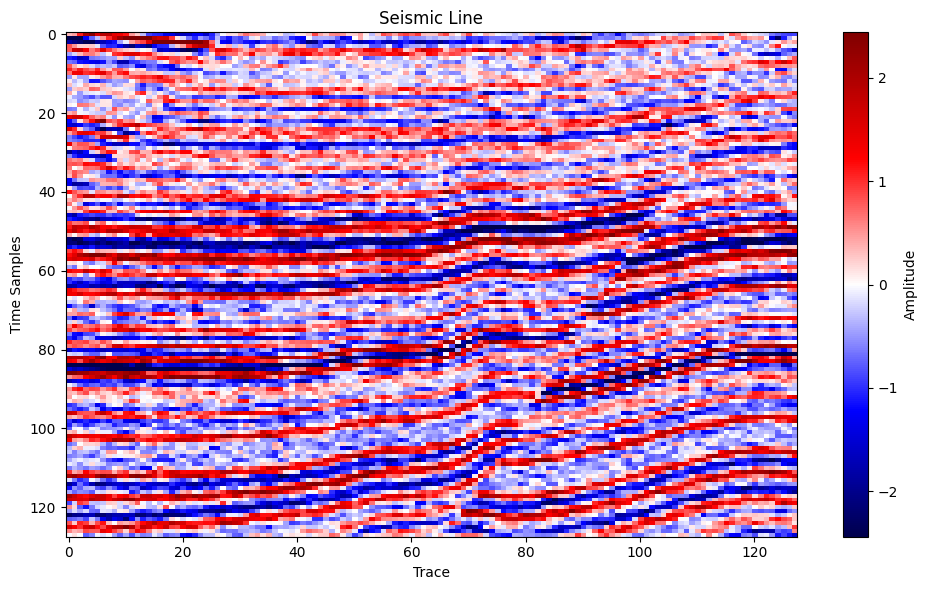

(128, 128)


In [2]:
test_data_path=f"{test_data_base}nx2.npy/3144.npy"
seismic_data_LR = np.load(test_data_path)
plot_2D_seismic(seismic_data_LR)
print(seismic_data_LR.shape)

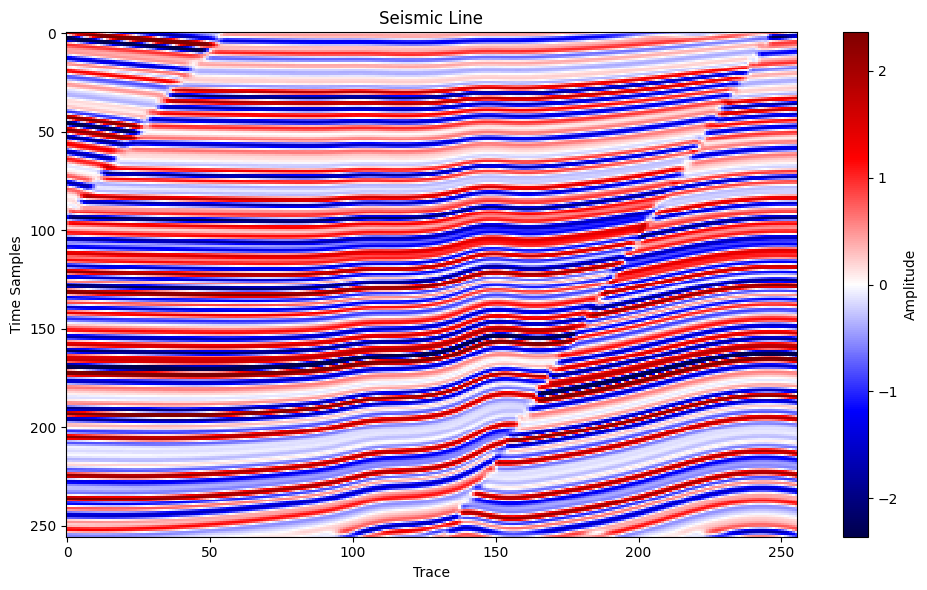

(256, 256)


In [3]:
test_data_path=f"{test_data_base}sx.npy/3144.npy"
seismic_data_HR = np.load(test_data_path)
plot_2D_seismic(seismic_data_HR)
print(seismic_data_HR.shape)

In [4]:
NOISE_LEVEL_LOW = {
    "coherent_lowfreq_noise": {"amp": 0.03},
    "smooth_random_noise":    {"std": 0.01},
    "trace_gain_loss":        {"prob": 0.02, "gain_min": 0.85, "gain_max": 1.0},
    "localized_spike":        {"n_spikes": 1, "amp": 0.1},
    "mild_phase_shift":       {"max_phase_deg": 3}
}

NOISE_LEVEL_MEDIUM = {
    "coherent_lowfreq_noise": {"amp": 0.08},
    "smooth_random_noise":    {"std": 0.03},
    "trace_gain_loss":        {"prob": 0.05, "gain_min": 0.6, "gain_max": 0.9},
    "localized_spike":        {"n_spikes": 3, "amp": 0.25},
    "mild_phase_shift":       {"max_phase_deg": 8}
}

NOISE_LEVEL_HIGH = {
    "coherent_lowfreq_noise": {"amp": 0.20},
    "smooth_random_noise":    {"std": 0.5},
    "trace_gain_loss":        {"prob": 0.30, "gain_min": 0.3, "gain_max": 0.8},
    "localized_spike":        {"n_spikes": 10, "amp": 0.5},
    "mild_phase_shift":       {"max_phase_deg": 30}
}

In [10]:
Cond_low_noise = apply_noise(seismic_data_LR, NOISE_LEVEL_LOW)
Cond_med_noise = apply_noise(seismic_data_LR, NOISE_LEVEL_MEDIUM)
Cond_high_noise = apply_noise(seismic_data_LR, NOISE_LEVEL_HIGH)

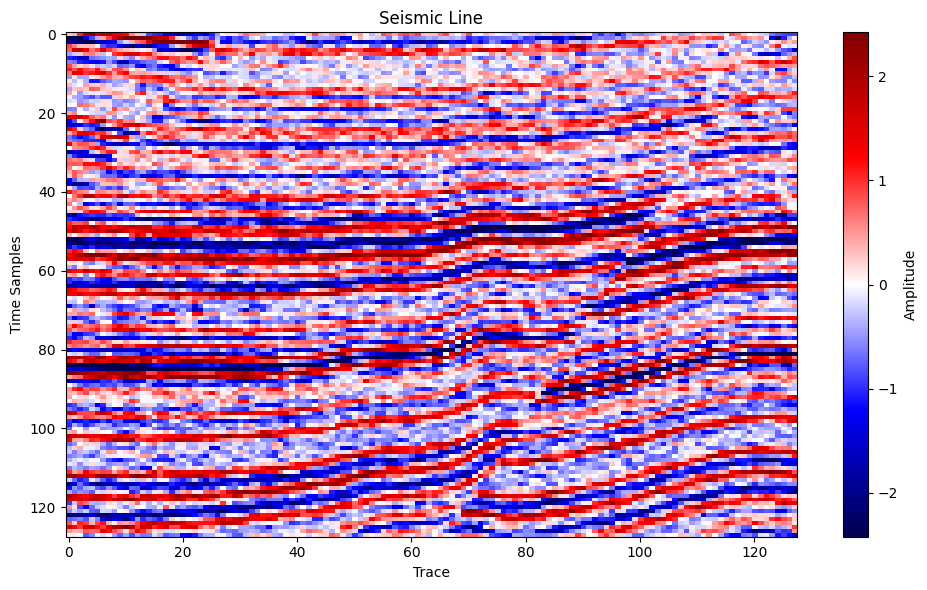

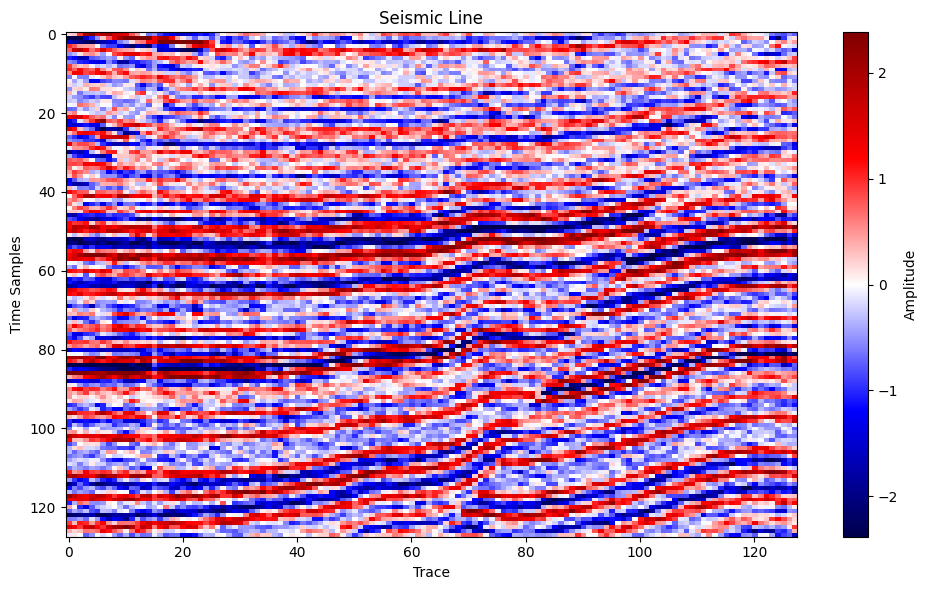

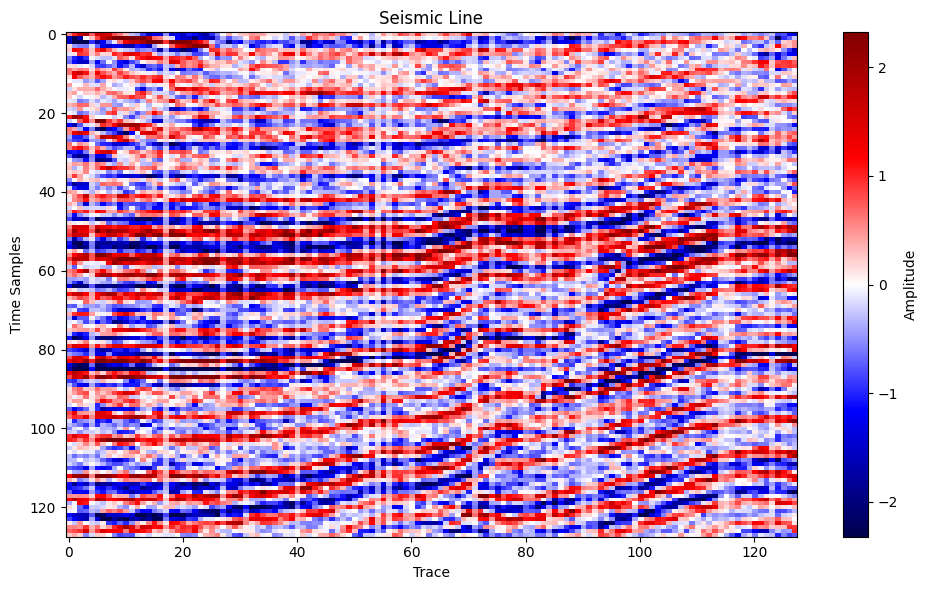

In [11]:
plot_2D_seismic(Cond_low_noise)
plot_2D_seismic(Cond_med_noise)
plot_2D_seismic(Cond_high_noise)

In [12]:
np.save(f"{project_root}Paper visualization/prediction/Denoising/High_noise/Cond_High_noise.npy",
        Cond_high_noise)
np.save(f"{project_root}Paper visualization/prediction/Denoising/Low_noise/Cond_Low_noise.npy",
        Cond_low_noise)
np.save(f"{project_root}Paper visualization/prediction/Denoising/Med_noise/Cond_Med_noise.npy",
        cond_med_noise)

In [13]:
np.save(f"{project_root}Paper visualization/prediction/Denoising/High_noise/GroundTruth.npy",
        seismic_data_HR)
np.save(f"{project_root}Paper visualization/prediction/Denoising/Low_noise/GroundTruth.npy",
        seismic_data_HR)
np.save(f"{project_root}Paper visualization/prediction/Denoising/Med_noise/GroundTruth.npy",
        seismic_data_HR)